# Tugas 2 : **Membuat Perhitungan manual dari teori konvolusi pada materi bab 4 Dan Membuat code dari fast fourier transform (fft), setiap mahasiswa implementasi mgunakan citra berbeda.**



NAMA : Mohammad Iqbal Surya Ramadhan

NIM  : 210411100002

MATA KULIAH : Pengolahan Citra - A

Tugas 2 Individu terakhir pengumpulan 25 Sept '24 jam 05.00

1. Kerjakan hitungan manual dari teori konvolusi pada materi pdf bab 4.

2. Buat code dari fast fourier transform (fft), setiap mahasiswa implementasi mgunakan citra berbeda.

 kirim file .py dan pdf (screenshot hasil running spt di slide ppt terlampir, ada image asli, proses fft, image stlh proses fft)

Maksimal pengumpulan tugas Rabu 25 September 2024 jam 05.00

**1. Kerjakan hitungan manual dari teori konvolusi**

**2. Membuat code dari fast fourier transform (fft), setiap mahasiswa implementasi mgunakan citra berbeda ( Menampilkan Image asli, proses fft dan Image setelah proses fft.)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


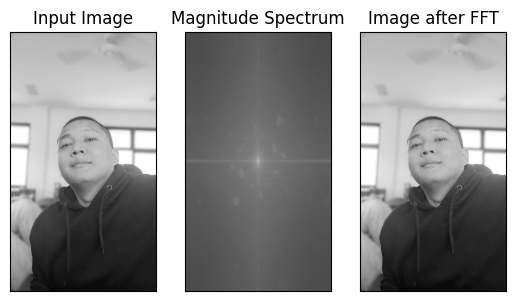

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from matplotlib import pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Load the image
img = cv2.imread("/content/drive/My Drive/PCDA/report/Tugas-PCDA/PCDA.jpg", 0)  # Replace 'your_image.jpg' with your image file

# Perform FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift))

# Display the original image, FFT magnitude spectrum, and inverse FFT image
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])

# Inverse FFT
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.subplot(133),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after FFT'), plt.xticks([]), plt.yticks([])

plt.show()


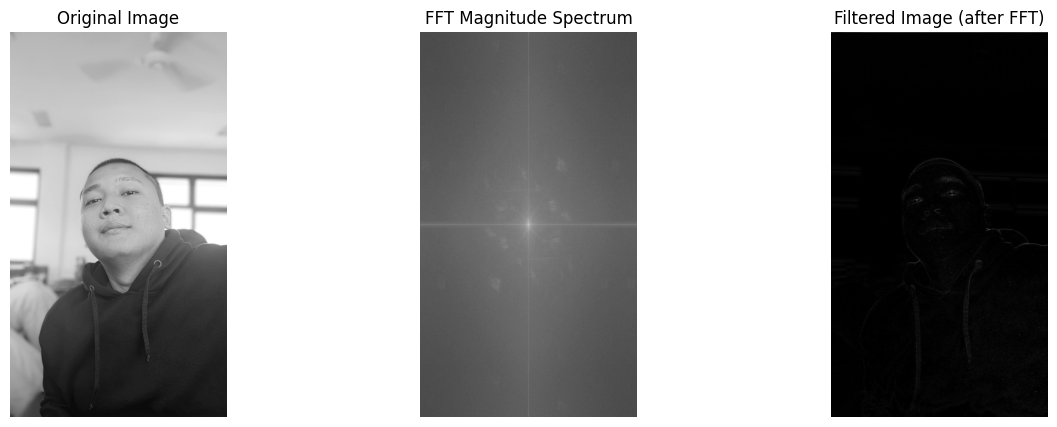

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift

# Fungsi untuk menampilkan gambar
def show_images(images, titles, cmap=None):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# 1. Load citra
image_path = "/content/drive/My Drive/PCDA/report/Tugas-PCDA/PCDA.jpg"  # Ubah ini dengan path citramu
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Citra tidak dapat dibaca. Periksa kembali path citramu.")

# Ubah citra menjadi float32 untuk proses FFT
image = np.float32(image)

# 2. Lakukan Fast Fourier Transform (FFT)
fft_image = fft2(image)       # FFT dua dimensi
fft_image_shifted = fftshift(fft_image)  # Pindahkan frekuensi nol ke tengah

# 3. Tampilkan citra asli dan spektrum FFT
magnitude_spectrum = np.log(np.abs(fft_image_shifted) + 1e-8)

# 4. Definisikan kernel 3x3 untuk konvolusi (contohnya untuk deteksi tepi)
kernel_3x3 = np.array([[-1, -1, -1],
                       [ 0,  0,  0],
                       [ 1,  1,  1]])

# 5. Terapkan FFT pada kernel, pad ukuran kernel agar sesuai dengan ukuran citra
fft_kernel = fft2(kernel_3x3, s=image.shape)

# Konvolusi di domain frekuensi
filtered_fft = fft_image * fft_kernel

# 6. Inverse FFT untuk mendapatkan citra hasil konvolusi
filtered_image = np.abs(ifft2(filtered_fft))

# 7. Tampilkan hasil
show_images([image, magnitude_spectrum, filtered_image],
            ['Original Image', 'FFT Magnitude Spectrum', 'Filtered Image (after FFT)'],
            cmap='gray')
